In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
#Import plotting means 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import plotly.graph_objects as go

In [3]:
#import master data set
master = pd.read_csv("C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Master Data/Master.csv")

In [4]:
#creation of production variables per capita
master['Total_Production_Value_Per_Capita'] = master['Total_Production_Value'] / master['Population']
master['Total_Reserves_Value_Per_Capita'] = master['Total_Reserves_Value'] / master['Population']

Variable Thematic Grouping

In [6]:
variable_groups = {
    'identifiers': [
        'Country Code', 'Country Name', 'Year'
    ],

        'economic_complexity_index': [
        'Economic Complexity Index'
    ],
    
    'resource_dependence': [
        'Oil rents (% of GDP)',
        'Natural gas rents (% of GDP)',
        'Mineral rents (% of GDP)',
        'Total natural resources rents (% of GDP)',
        'Total_Production',
        'Total_Reserves',
        'Total_Production_Value',
        'Total_Reserves_Value',
        'Total_Production_Value_Per_Capita',
        'Total_Reserves_Value_Per_Capita',
        'Hydrocarbons_Dominant',
        'Subsoil_Metals_Dominant',
        'Precious_Metals_Dominant'
    ],
    
    'economic_structure': [
        'Trade (% of GDP)',
        'Agriculture',
        'Industry',
        'Manufacturing',
        'Services'
    ],
    
    'macroeconomic_indicators': [
        'GDP per capita (constant prices, PPP)',
        'Inflation, consumer prices (annual %)',
        'Share of consumption in GDP',
        'Share of investment in GDP',
        'Share of government spending in GDP',
        'Gross fixed capital formation, all, Constant prices, Percent of GDP',
        'Capital depreciation rate'
    ],
    
    'fiscal_financial': [
        'Government revenue',
        'Primary net lending, General government, Percent of GDP',
        'Adjusted savings: gross savings (% of GNI)',
        'Domestic credit to private sector (% of GDP)',
        'Lending interest rate (%)',
        'Real interest rate (%)',
        'Use of IMF credit (DOD, current US$)'
    ],
    
    'governance_institutions': [
        'Rule of law index',
        'Political corruption index',
        'Clientelism index',
        'Property rights',
        'Political stability — estimate'
    ],
    
    'human_capital_development': [
        'Human capital index',
        'Life expectancy at birth, total (years)',
        'Death rates, crude per 1000 people'
    ],
    
    'infrastructure_technology': [
        'Access to electricity (% of population)',
        'Mobile cellular subscriptions (per 100 people)'
    ],
    
    'structural_characteristics': [
        'Landlocked',
        'Urban population (% of total population)',
        'Population'
    ]
}

In [7]:
def create_descriptive_table(df, variable_groups, exclude_groups=['identifiers']):
    """
    Create descriptive statistics tables for each variable group
    
    Parameters:
    - df: your master dataframe
    - variable_groups: dictionary with theme names as keys and variable lists as values
    - exclude_groups: list of group names to skip
    """
    
    all_tables = {}
    
    for group_name, variables in variable_groups.items():
        if group_name in exclude_groups:
            continue
        
        # Get variables that exist in the dataframe
        existing_vars = [v for v in variables if v in df.columns]
        
        if not existing_vars:
            continue
        
        # Calculate statistics
        stats_data = []
        
        for var in existing_vars:
            stats_data.append({
                'Variable': var,
                'Mean': df[var].mean(),
                'Std': df[var].std(),
                'Median': df[var].median(),
                'Q1': df[var].quantile(0.25),
                'Q3': df[var].quantile(0.75),
                'N': df[var].count()
            })
        
        # Create dataframe for this group
        group_table = pd.DataFrame(stats_data)
        
        # Round numeric columns
        numeric_cols = ['Mean', 'Std', 'Median', 'Q1', 'Q3']
        group_table[numeric_cols] = group_table[numeric_cols].round(3)
        
        all_tables[group_name] = group_table
        
        # Display the table
        print(f"\n{'='*80}")
        print(f"{group_name.upper().replace('_', ' ')}")
        print(f"{'='*80}")
        print(group_table.to_string(index=False))
        print()
    
    return all_tables

# Usage
descriptive_tables = create_descriptive_table(master, variable_groups)


ECONOMIC COMPLEXITY INDEX
                 Variable  Mean   Std  Median     Q1    Q3    N
Economic Complexity Index -0.07 1.024  -0.209 -0.832 0.586 3150


RESOURCE DEPENDENCE
                                Variable         Mean          Std       Median           Q1           Q3    N
                    Oil rents (% of GDP) 5.318000e+00 1.137100e+01 1.990000e-01 0.000000e+00 3.333000e+00 3150
            Natural gas rents (% of GDP) 6.530000e-01 1.677000e+00 2.100000e-02 0.000000e+00 4.200000e-01 3150
                Mineral rents (% of GDP) 8.590000e-01 2.266000e+00 4.600000e-02 0.000000e+00 5.170000e-01 3150
Total natural resources rents (% of GDP) 8.948000e+00 1.222700e+01 3.580000e+00 8.070000e-01 1.224300e+01 3150
                        Total_Production 1.065785e+09 3.348657e+09 1.460838e+07 9.092590e+04 6.990435e+08 3150
                          Total_Reserves 1.168245e+09 4.385390e+09 0.000000e+00 0.000000e+00 3.465148e+08 3150
                  Total_Production_Value 1.476

In [14]:
# Calculate statistics
eci_stats = master.groupby('Year')['Economic Complexity Index'].agg([
    ('Mean', 'mean'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
]).reset_index()

fig = go.Figure()

# Add interquartile range as shaded area
fig.add_trace(go.Scatter(
    x=eci_stats['Year'].tolist() + eci_stats['Year'].tolist()[::-1],
    y=eci_stats['Q3'].tolist() + eci_stats['Q1'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(44, 62, 80, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=True,
    name='Interquartile Range',
    hoverinfo='skip'
))

# Add mean line
fig.add_trace(go.Scatter(
    x=eci_stats['Year'],
    y=eci_stats['Mean'],
    mode='lines+markers',
    line=dict(color='#2C3E50', width=2.5),
    marker=dict(size=6, color='#2C3E50'),
    name='Mean'
))

fig.update_layout(
    title={
        'text': 'Evolution of Economic Complexity Index',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16, 'color': '#2C3E50'}
    },
    xaxis_title='Year',
    yaxis_title='Economic Complexity Index',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial, sans-serif", size=12, color='#2C3E50'),
    xaxis=dict(
        showgrid=True,
        gridcolor='#E5E5E5',
        showline=True,
        linecolor='#2C3E50',
        linewidth=1
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#E5E5E5',
        showline=True,
        linecolor='#2C3E50',
        linewidth=1
    ),
    hovermode='x unified',
    width=900,
    height=500,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#E5E5E5',
        borderwidth=1
    )
)

fig.show()

Plot is not useful because ECI is normalized each year. 

## Heatmap


Correlation Summary by Theme:
                             mean    min    max
Theme                                          
Economic Structure          0.105 -0.552  0.631
Fiscal Financial            0.122 -0.297  0.672
Governance Institutions     0.088 -0.675  0.668
Human Capital Development   0.457 -0.048  0.739
Infrastructure Technology   0.481  0.349  0.613
Macroeconomic Indicators    0.110 -0.223  0.597
Resource Dependence        -0.061 -0.472  0.195
Structural Characteristics  0.081 -0.072  0.205


Top 10 Positive Correlations with ECI:
                                    Variable                     Theme  Correlation
                         Human capital index Human Capital Development     0.739458
     Life expectancy at birth, total (years) Human Capital Development     0.678240
Domestic credit to private sector (% of GDP)          Fiscal Financial     0.672480
                           Rule of law index   Governance Institutions     0.667558
                            

# High Natural Resource Countries

Conditions for filtering the subsample

In [16]:
#high_resource_countries = master[
#    ((master['Total natural resources rents (% of GDP)'] >= 5) & 
#     (master['Year'] == 1995) & 
#     (master['Income1995'] != 'High-income countries')) |
#    ((master['Country Name'].isin(['United Arab Emirates', 'Kuwait', 'Qatar'])) & 
#     (master['Year'] == 1995))
#]

In [8]:
#selecting countries
high_resource_countries_df = master[master['Country Code'].isin(['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'])]

In [9]:
#save subsample
high_resource_countries_df.to_csv("C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Master Data/high_resource_countries.csv")

Merge subsample with cluster labels

In [10]:
#import cluster labels
cluster_1995 = pd.read_csv("C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Master Data/clusters1995.csv")

In [11]:
cluster_1995=cluster_1995[['Country Code', 'Cluster']]

In [12]:
high_resource_countries_df = high_resource_countries_df.merge(cluster_1995, on=['Country Code'], how='left')

Descriptive statistics table for subsample and master

In [15]:

import pandas as pd
import numpy as np

# ── Variables ──────────────────────────────────────────────────────────────────
vars_continuous = [
    'Economic Complexity Index',
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political stability — estimate',
    'Rule of law index',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'Domestic credit to private sector (% of GDP)',
]

vars_binary = [
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
]

all_vars = vars_continuous + vars_binary

# ── Pretty labels (optional — edit as needed) ──────────────────────────────────
labels = {
    'Economic Complexity Index':                        'Economic Complexity Index (ECI)',
    'lHuman capital index':                                          'Human Capital Index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP': 'Gross Fixed Capital Formation',
    'Political stability — estimate':                   'Political Stability',
    'Rule of law index':                                'Rule of Law Index',
    'Total_Production_Value_Per_Capita':                'Natural Resource Production Value Per Capita',
    'Trade (% of GDP)':                                 'Trade (% of GDP)',
    'Hydrocarbons_Dominant':                            'Hydrocarbons Dominant (=1)',
    'Subsoil_Metals_Dominant':                          'Subsoil Metals Dominant (=1)',
    'Precious_Metals_Dominant':                         'Precious Metals Dominant (=1)',
    'Access to electricity (% of population)':         'Access to Electricity (% of pop.)',
    'Adjusted savings: gross savings (% of GNI)':      'Gross Savings (% of GNI)',
    'Domestic credit to private sector (% of GDP)':    'Domestic Credit to Private Sector (% of GDP)',
}

# ── Core stats function ────────────────────────────────────────────────────────
def compute_stats(df, varlist, binary_vars):
    rows = []
    for v in varlist:
        col = df[v].dropna()
        n   = col.count()
        if v in binary_vars:
            # For dummies: show share (mean) and N only
            rows.append({
                'Variable': labels.get(v, v),
                'N':        n,
                'Mean':     col.mean(),
                'Std. Dev.':np.nan,
                'Min':      np.nan,
                'p25':      np.nan,
                'Median':   np.nan,
                'p75':      np.nan,
                'Max':      np.nan,
                '_is_binary': True,
            })
        else:
            rows.append({
                'Variable': labels.get(v, v),
                'N':        n,
                'Mean':     col.mean(),
                'Std. Dev.':col.std(),
                'Min':      col.min(),
                'p25':      col.quantile(0.25),
                'Median':   col.median(),
                'p75':      col.quantile(0.75),
                'Max':      col.max(),
                '_is_binary': False,
            })
    return pd.DataFrame(rows)

# ── Build both stat blocks ─────────────────────────────────────────────────────
stats_master   = compute_stats(master,               all_vars, vars_binary)
stats_hrc      = compute_stats(high_resource_countries_df, all_vars, vars_binary)

# ── Format helper ──────────────────────────────────────────────────────────────
def fmt(val, is_binary=False, col=None):
    if pd.isna(val):
        return '—'
    if col == 'N':
        return f'{int(val):,}'
    if is_binary and col == 'Mean':
        return f'{val:.1%}'          # e.g. 43.2 %
    return f'{val:.3f}'

stat_cols = ['N', 'Mean', 'Std. Dev.', 'Min', 'p25', 'Median', 'p75', 'Max']

def format_block(stats_df):
    rows = []
    for _, r in stats_df.iterrows():
        row = {'Variable': r['Variable']}
        for c in stat_cols:
            row[c] = fmt(r[c], is_binary=r['_is_binary'], col=c)
        rows.append(row)
    return pd.DataFrame(rows).set_index('Variable')

tbl_master = format_block(stats_master)
tbl_hrc    = format_block(stats_hrc)

# ── Combine with multi-level columns ──────────────────────────────────────────
tbl_combined = pd.concat(
    [tbl_master, tbl_hrc],
    axis=1,
    keys=['Full Sample', 'High-Resource Countries']
)

# ── Display ────────────────────────────────────────────────────────────────────
print(tbl_combined.to_string())

                                             Full Sample                                                                 High-Resource Countries                                                                   
                                                       N     Mean Std. Dev.      Min     p25  Median      p75        Max                       N      Mean Std. Dev.      Min     p25   Median       p75        Max
Variable                                                                                                                                                                                                           
Economic Complexity Index (ECI)                    3,150   -0.070     1.024   -2.890  -0.832  -0.209    0.586      2.718                   1,350    -0.760     0.670   -2.890  -1.220   -0.804    -0.343      1.211
Human capital index                                3,150    2.457     0.690    1.049   1.876   2.504    3.019      3.813                   1,350     2.0

Export to HTML

In [ ]:
import pandas as pd
import numpy as np

# ── Variables ──────────────────────────────────────────────────────────────────
vars_continuous = [
    'Economic Complexity Index',
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political stability — estimate',
    'Rule of law index',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'Domestic credit to private sector (% of GDP)',
]

vars_binary = [
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
]

all_vars = vars_continuous + vars_binary

labels = {
    'Economic Complexity Index':                                               'Economic Complexity Index (ECI)',
    'Human capital index':                                                     'Human Capital Index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':    'Gross Fixed Capital Formation (% of GDP)',
    'Political stability — estimate':                                          'Political Stability',
    'Rule of law index':                                                       'Rule of Law Index',
    'Total_Production_Value_Per_Capita':                                       'Natural Resource Production Value Per Capita',
    'Trade (% of GDP)':                                                        'Trade (% of GDP)',
    'Hydrocarbons_Dominant':                                                   'Hydrocarbons Dominant (=1)',
    'Subsoil_Metals_Dominant':                                                 'Subsoil Metals Dominant (=1)',
    'Precious_Metals_Dominant':                                                'Precious Metals Dominant (=1)',
    'Access to electricity (% of population)':                                'Access to Electricity (% of pop.)',
    'Adjusted savings: gross savings (% of GNI)':                             'Gross Savings (% of GNI)',
    'Domestic credit to private sector (% of GDP)':                           'Domestic Credit to Private Sector (% of GDP)',
}

# ── Core stats function ────────────────────────────────────────────────────────
def compute_stats(df, varlist, binary_vars):
    rows = []
    for v in varlist:
        col = df[v].dropna()
        is_bin = v in binary_vars
        rows.append({
            'Variable':   labels.get(v, v),
            'N':          col.count(),
            'Mean':       col.mean(),
            'Std. Dev.':  np.nan if is_bin else col.std(),
            'Min':        np.nan if is_bin else col.min(),
            'p25':        np.nan if is_bin else col.quantile(0.25),
            'Median':     np.nan if is_bin else col.median(),
            'p75':        np.nan if is_bin else col.quantile(0.75),
            'Max':        np.nan if is_bin else col.max(),
            '_is_binary': is_bin,
        })
    return pd.DataFrame(rows)

stats_master = compute_stats(master,                all_vars, vars_binary)
stats_hrc    = compute_stats(high_resource_countries_df, all_vars, vars_binary)

# ── Format helper ──────────────────────────────────────────────────────────────
stat_cols = ['N', 'Mean', 'Std. Dev.', 'Min', 'p25', 'Median', 'p75', 'Max']

def fmt(val, is_binary=False, col=None):
    if pd.isna(val):   return '—'
    if col == 'N':     return f'{int(val):,}'
    if is_binary and col == 'Mean': return f'{val*100:.1f}%'
    return f'{val:.3f}'

# ── HTML export ────────────────────────────────────────────────────────────────
def build_html(stats_m, stats_h):
    css = """
    <style>
      body { font-family: "Times New Roman", Times, serif; font-size: 13px; margin: 40px; color: #000; }
      h2   { font-size: 14px; font-weight: normal; text-align: center; margin-bottom: 4px; }
      table { border-collapse: collapse; width: 820px; margin: 0 auto; }
      th, td { padding: 3px 8px; text-align: center; }
      td.varname { text-align: left; padding-left: 4px; min-width: 220px; }
      .top-border { border-top: 2px solid #000; }
      .mid-border { border-top: 1px solid #000; }
      .bot-border { border-bottom: 2px solid #000; }
      .note { font-size: 11px; text-align: left; width: 820px; margin: 6px auto 0; }
      .section-label { font-style: italic; text-align: left; padding-left: 4px;
                       padding-top: 6px; font-size: 12px; color: #333; }
      .group-header { background-color: #f5f5f5; font-weight: bold; font-size: 11px; }
    </style>
    """

    header_row1 = (
        '<tr class="top-border">'
        '<th></th>'
        f'<th colspan="{len(stat_cols)}" style="border-bottom:1px solid #000">Full Sample</th>'
        f'<th colspan="{len(stat_cols)}" style="border-bottom:1px solid #000">High-Resource Countries</th>'
        '</tr>'
    )
    col_heads = ''.join(f'<th>{c}</th>' for c in stat_cols)
    header_row2 = (
        f'<tr class="mid-border bot-border"><th></th>{col_heads}{col_heads}</tr>'
    )

    def data_rows(stats_m, stats_h, section_label=None):
        html = ''
        if section_label:
            html += f'<tr><td class="varname section-label" colspan="{1 + len(stat_cols)*2}">{section_label}</td></tr>'
        for (_, rm), (_, rh) in zip(stats_m.iterrows(), stats_h.iterrows()):
            is_bin = rm['_is_binary']
            cells_m = ''.join(f'<td>{fmt(rm[c], is_bin, c)}</td>' for c in stat_cols)
            cells_h = ''.join(f'<td>{fmt(rh[c], is_bin, c)}</td>' for c in stat_cols)
            html += f'<tr><td class="varname">{rm["Variable"]}</td>{cells_m}{cells_h}</tr>\n'
        return html

    # Split into continuous and binary blocks
    cont_m = stats_m[~stats_m['_is_binary']].reset_index(drop=True)
    cont_h = stats_h[~stats_h['_is_binary']].reset_index(drop=True)
    bin_m  = stats_m[stats_m['_is_binary']].reset_index(drop=True)
    bin_h  = stats_h[stats_h['_is_binary']].reset_index(drop=True)

    body = (
        data_rows(cont_m, cont_h, 'Continuous variables') +
        '<tr class="mid-border"><td colspan="' + str(1 + len(stat_cols)*2) + '"></td></tr>' +
        data_rows(bin_m,  bin_h,  'Binary variables (share = mean)')
    )

    # Footer: N countries
    n_obs_m = int(master.shape[0])
    n_obs_h = int(high_resource_countries.shape[0])
    n_cnt_m = master['country'].nunique() if 'country' in master.columns else '—'
    n_cnt_h = high_resource_countries['country'].nunique() if 'country' in high_resource_countries.columns else '—'

    footer = f"""
    <tr class="mid-border">
      <td class="varname">Observations</td>
      <td colspan="{len(stat_cols)}">{n_obs_m:,}</td>
      <td colspan="{len(stat_cols)}">{n_obs_h:,}</td>
    </tr>
    <tr class="bot-border">
      <td class="varname">Countries</td>
      <td colspan="{len(stat_cols)}">{n_cnt_m}</td>
      <td colspan="{len(stat_cols)}">{n_cnt_h}</td>
    </tr>
    """

    note = (
        '<p class="note"><em>Note:</em> Statistics computed on non-missing observations. '
        'Binary variables report the share of country-year observations equal to 1. '
        'Std. Dev., Min, quartiles and Max are omitted for binary variables.</p>'
    )

    html = f"""<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8">{css}</head>
<body>
<h2>Descriptive Statistics</h2>
<table>
  <thead>{header_row1}{header_row2}</thead>
  <tbody>
  {body}
  {footer}
  </tbody>
</table>
{note}
</body>
</html>"""
    return html

# ── Write to file ──────────────────────────────────────────────────────────────
html_out = build_html(stats_master, stats_hrc)

with open('descriptive_statistics.html', 'w', encoding='utf-8') as f:
    f.write(html_out)

print("Saved → descriptive_statistics.html")

Saved → descriptive_statistics.html


Correlation vector by theme

In [17]:
import plotly.graph_objects as go
import pandas as pd

def create_eci_correlation_heatmap(df, variable_groups, exclude_groups=['identifiers', 'economic_complexity_index']):
    """
    Create a heatmap showing ECI correlation with all variables, grouped by theme
    """
    
    # Collect all variables with their themes and correlations
    data_list = []
    
    for group_name, vars_list in variable_groups.items():
        if group_name in exclude_groups:
            continue
        
        existing_vars = [v for v in vars_list if v in df.columns]
        
        for var in existing_vars:
            # Calculate correlation
            corr = df[['Economic Complexity Index', var]].corr().iloc[0, 1]
            
            data_list.append({
                'Theme': group_name.replace('_', ' ').title(),
                'Variable': var,
                'Correlation': corr
            })
    
    # Create dataframe
    corr_df = pd.DataFrame(data_list)
    
    # Sort by theme first, then by correlation within each theme
    corr_df = corr_df.sort_values(['Theme', 'Correlation'], ascending=[True, False])
    
    # Reset index to get proper ordering
    corr_df = corr_df.reset_index(drop=True)
    
    # Create the heatmap data
    z_values = corr_df['Correlation'].values.reshape(-1, 1)
    y_labels = corr_df['Variable'].tolist()
    
    # Create heatmap
    fig = go.Figure(data=go.Heatmap(
        z=z_values,
        y=y_labels,
        x=['Correlation with ECI'],
        colorscale=[
            [0, '#D73027'],      # Strong negative (red)
            [0.25, '#FC8D59'],   # Moderate negative (orange)
            [0.5, '#FFFFBF'],    # Near zero (light yellow)
            [0.75, '#91BFDB'],   # Moderate positive (light blue)
            [1, '#4575B4']       # Strong positive (dark blue)
        ],
        zmid=0,
        text=z_values,
        texttemplate='%{text:.3f}',
        textfont={"size": 9},
        colorbar=dict(
            title="Correlation",
            tickmode="linear",
            tick0=-1,
            dtick=0.25,
            thickness=15,
            len=0.7
        ),
        hovertemplate='<b>%{y}</b><br>Correlation: %{z:.3f}<extra></extra>'
    ))
    
    # Find theme boundaries and create separators
    theme_boundaries = []
    theme_midpoints = []
    theme_labels = []
    
    current_theme = None
    theme_start = 0
    
    for idx, row in corr_df.iterrows():
        if current_theme != row['Theme']:
            if current_theme is not None:
                # Add boundary line
                theme_boundaries.append(idx - 0.5)
                # Calculate midpoint for previous theme
                theme_midpoints.append((theme_start + idx - 1) / 2)
                theme_labels.append(current_theme)
            
            current_theme = row['Theme']
            theme_start = idx
    
    # Add last theme
    if current_theme is not None:
        theme_midpoints.append((theme_start + len(corr_df) - 1) / 2)
        theme_labels.append(current_theme)
    
    # Update layout
    fig.update_layout(
        title={
            'text': 'Economic Complexity Index - Correlation Matrix by Theme',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 16, 'color': '#2C3E50', 'family': 'Arial, sans-serif'}
        },
        xaxis=dict(
            side='top',
            showgrid=False,
            showline=True,
            linecolor='#2C3E50',
            linewidth=1
        ),
        yaxis=dict(
            showgrid=False,
            showline=True,
            linecolor='#2C3E50',
            linewidth=1,
            tickfont=dict(size=9),
            autorange='reversed'  # This ensures top to bottom ordering
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        font=dict(family="Arial, sans-serif", size=11, color='#2C3E50'),
        height=max(800, len(y_labels) * 18),
        width=900,
        margin=dict(l=350, r=150, t=100, b=50)
    )
    
    # Add horizontal lines to separate themes
    shapes = []
    for boundary in theme_boundaries:
        shapes.append(dict(
            type='line',
            x0=-0.55, x1=0.55,
            y0=boundary, y1=boundary,
            line=dict(color='#2C3E50', width=2),
            xref='x',
            yref='y'
        ))
    
    fig.update_layout(shapes=shapes)
    
    # Add theme labels on the left side
    annotations = []
    for label, midpoint in zip(theme_labels, theme_midpoints):
        annotations.append(dict(
            x=-0.75,
            y=midpoint,
            text=f'<b>{label}</b>',
            showarrow=False,
            xanchor='right',
            yanchor='middle',
            font=dict(size=11, color='#2C3E50', family='Arial, sans-serif'),
            xref='x',
            yref='y',
            textangle=0
        ))
    
    fig.update_layout(annotations=annotations)
    
    return fig, corr_df

In [18]:
# Create the heatmap
fig, corr_data = create_eci_correlation_heatmap(high_resource_countries_df, variable_groups)
fig.show()

# Print summary statistics
print("\nCorrelation Summary by Theme:")
print(corr_data.groupby('Theme')['Correlation'].agg(['mean', 'min', 'max']).round(3))

print("\n\nTop 10 Positive Correlations with ECI:")
print(corr_data.nlargest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

print("\n\nTop 10 Negative Correlations with ECI:")
print(corr_data.nsmallest(10, 'Correlation')[['Variable', 'Theme', 'Correlation']].to_string(index=False))

fig.write_html('C:/Users/emili/OneDrive/Documentos/LSE MPA DSPP/AT 2025/Capstone/Descriptive Statistics/eci_correlation_heatmap.html')


Correlation Summary by Theme:
                             mean    min    max
Theme                                          
Economic Structure          0.118 -0.309  0.327
Fiscal Financial            0.128 -0.278  0.582
Governance Institutions     0.010 -0.393  0.316
Human Capital Development   0.211 -0.387  0.512
Infrastructure Technology   0.405  0.314  0.497
Macroeconomic Indicators    0.060 -0.216  0.430
Resource Dependence         0.136 -0.136  0.433
Structural Characteristics  0.089 -0.066  0.221


Top 10 Positive Correlations with ECI:
                                    Variable                     Theme  Correlation
Domestic credit to private sector (% of GDP)          Fiscal Financial     0.581617
                         Human capital index Human Capital Development     0.512310
     Life expectancy at birth, total (years) Human Capital Development     0.507606
     Access to electricity (% of population) Infrastructure Technology     0.497311
                            

# Summary Statistics by Resource Type

In [20]:
# Compare key indicators across resource types
resource_comparison = []

for resource_type in ['Hydrocarbons_Dominant', 'Subsoil_Metals_Dominant', 'Precious_Metals_Dominant']:
    subset = high_resource_countries_df[high_resource_countries_df[resource_type] == 1]
    
    resource_comparison.append({
        'Resource Type': resource_type.replace('_', ' ').replace(' Dominant', ''),
        'N Countries': subset['Country Name'].nunique(),
        'Avg ECI': subset['Economic Complexity Index'].mean(),
        'Avg Manufacturing %': subset['Manufacturing'].mean(),
        'Avg Production Value Per Capita': subset['Total_Production_Value_Per_Capita'].mean(),
        'Avg GDP per capita': subset['GDP per capita (constant prices, PPP)'].mean()
    })

comparison_table = pd.DataFrame(resource_comparison)
print(comparison_table.round(2))

     Resource Type  N Countries  Avg ECI  Avg Manufacturing %  \
0     Hydrocarbons           35    -0.64                12.51   
1   Subsoil Metals           13    -0.98                11.48   
2  Precious Metals           18    -0.88                 9.40   

   Avg Production Value Per Capita  Avg GDP per capita  
0                          2594.16            20350.48  
1                           353.21             6739.99  
2                            40.56             2269.27  


In [21]:
comparison_table = pd.DataFrame(resource_comparison)

styled_table = (comparison_table.style
    .format({
        'N Countries': '{:.0f}',
        'Avg ECI': '{:.2f}',
        'Avg Manufacturing %': '{:.1f}%',
        'Avg Production Value Per Capita': '{:.0f}',
        'Avg GDP per capita': '${:,.0f}'
    })
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2C5F8D'), 
                                      ('color', 'white'),
                                      ('font-weight', 'bold'),
                                      ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
    ])
    .hide(axis='index')
)

styled_table

Resource Type,N Countries,Avg ECI,Avg Manufacturing %,Avg Production Value Per Capita,Avg GDP per capita
Hydrocarbons,35,-0.64,12.5%,2594,"$20,350"
Subsoil Metals,13,-0.98,11.5%,353,"$6,740"
Precious Metals,18,-0.88,9.4%,41,"$2,269"


# Winners vs Losers Table

In [22]:
# Add percentile ranks for initial and final years
initial_year = high_resource_countries_df['Year'].min()
final_year = high_resource_countries_df['Year'].max()

initial_eci = high_resource_countries_df[high_resource_countries_df['Year'] == initial_year].copy()
final_eci = high_resource_countries_df[high_resource_countries_df['Year'] == final_year].copy()

initial_eci['ECI_Percentile_Initial'] = initial_eci['Economic Complexity Index'].rank(pct=True) * 100
final_eci['ECI_Percentile_Final'] = final_eci['Economic Complexity Index'].rank(pct=True) * 100

eci_change = initial_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Initial']].merge(
    final_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Final']],
    on='Country Name',
    suffixes=('_Initial', '_Final')
)

eci_change['ECI_Change'] = eci_change['Economic Complexity Index_Final'] - eci_change['Economic Complexity Index_Initial']

# Sort by absolute ECI change
eci_change = eci_change.sort_values('ECI_Change', ascending=False)

# Clean up column names for display
eci_change_display = eci_change[[
    'Country Name', 
    'ECI_Change',
    'ECI_Percentile_Initial',
    'ECI_Percentile_Final'
]].copy()

# Round percentiles to no decimals
eci_change_display['ECI_Percentile_Initial'] = eci_change_display['ECI_Percentile_Initial'].round(0).astype(int)
eci_change_display['ECI_Percentile_Final'] = eci_change_display['ECI_Percentile_Final'].round(0).astype(int)

eci_change_display.columns = [
    'Country', 
    'ECI Change',
    'Percentile (1995)',
    'Percentile (2019)'
]

print("=" * 80)
print(f"Top 10 ECI Improvers (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("=" * 80)
print(eci_change_display.head(10).to_string(index=False))

print("\n" + "=" * 80)
print(f"Top 10 ECI Decliners (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("=" * 80)
print(eci_change_display.tail(10).to_string(index=False))

Top 10 ECI Improvers (Resource-Rich Countries, 1995-2019)
           Country  ECI Change  Percentile (1995)  Percentile (2019)
  Papua New Guinea       1.011                  2                 15
          Viet Nam       0.985                 31                 83
           Bahrain       0.903                 63                 96
          Malaysia       0.876                 96                100
Iran, Islamic Rep.       0.855                 41                 87
            Angola       0.710                  7                 30
            Kuwait       0.676                 78                 94
             Qatar       0.660                 54                 85
           Nigeria       0.609                  6                  7
           Lao PDR       0.552                 15                 59

Top 10 ECI Decliners (Resource-Rich Countries, 1995-2019)
      Country  ECI Change  Percentile (1995)  Percentile (2019)
      Liberia      -0.402                 61                

Add percentiles for initial and final years and export

In [23]:
# Add percentile ranks for initial and final years
initial_year = high_resource_countries_df['Year'].min()
final_year = high_resource_countries_df['Year'].max()

initial_eci = high_resource_countries_df[high_resource_countries_df['Year'] == initial_year].copy()
final_eci = high_resource_countries_df[high_resource_countries_df['Year'] == final_year].copy()

initial_eci['ECI_Percentile_Initial'] = initial_eci['Economic Complexity Index'].rank(pct=True) * 100
final_eci['ECI_Percentile_Final'] = final_eci['Economic Complexity Index'].rank(pct=True) * 100

eci_change = initial_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Initial']].merge(
    final_eci[['Country Name', 'Economic Complexity Index', 'ECI_Percentile_Final']],
    on='Country Name',
    suffixes=('_Initial', '_Final')
)

eci_change['ECI_Change'] = eci_change['Economic Complexity Index_Final'] - eci_change['Economic Complexity Index_Initial']

# Sort by absolute ECI change
eci_change = eci_change.sort_values('ECI_Change', ascending=False)

# Prepare display dataframes
eci_improvers = eci_change.head(10).copy()
eci_decliners = eci_change.tail(10).copy()

# Format the dataframes
for df in [eci_improvers, eci_decliners]:
    df['ECI_Change'] = df['ECI_Change'].round(3)
    df['ECI_Percentile_Initial'] = df['ECI_Percentile_Initial'].round(0).astype(int)
    df['ECI_Percentile_Final'] = df['ECI_Percentile_Final'].round(0).astype(int)

# Rename columns
eci_improvers = eci_improvers.rename(columns={
    'Country Name': 'Country',
    'ECI_Change': 'ECI Change',
    'ECI_Percentile_Initial': f'Percentile ({int(initial_year)})',
    'ECI_Percentile_Final': f'Percentile ({int(final_year)})'
})

eci_decliners = eci_decliners.rename(columns={
    'Country Name': 'Country',
    'ECI_Change': 'ECI Change',
    'ECI_Percentile_Initial': f'Percentile ({int(initial_year)})',
    'ECI_Percentile_Final': f'Percentile ({int(final_year)})'
})

# Select only the columns we want
display_cols = ['Country', 'ECI Change', f'Percentile ({int(initial_year)})', f'Percentile ({int(final_year)})']
eci_improvers = eci_improvers[display_cols]
eci_decliners = eci_decliners[display_cols]

# Create HTML with custom styling
html_template = """
<!DOCTYPE html>
<html>
<head>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            margin: 40px;
            background-color: #f5f5f5;
        }}
        h2 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
            margin-top: 40px;
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
            background-color: white;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }}
        th {{
            background-color: #3498db;
            color: white;
            text-align: left;
            padding: 12px;
            font-weight: 600;
        }}
        td {{
            padding: 10px 12px;
            border-bottom: 1px solid #ddd;
        }}
        tr:hover {{
            background-color: #f8f9fa;
        }}
        tr:last-child td {{
            border-bottom: none;
        }}
        .positive {{
            color: #27ae60;
            font-weight: 600;
        }}
        .negative {{
            color: #e74c3c;
            font-weight: 600;
        }}
        .country {{
            font-weight: 600;
            color: #2c3e50;
        }}
    </style>
</head>
<body>
    <h2>Top 10 ECI Improvers (Resource-Rich Countries, {start_year}-{end_year})</h2>
    {improvers_table}
    
    <h2>Top 10 ECI Decliners (Resource-Rich Countries, {start_year}-{end_year})</h2>
    {decliners_table}
</body>
</html>
"""

# Convert dataframes to HTML
improvers_html = eci_improvers.to_html(
    classes='data-table',
    escape=False,
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x
)

decliners_html = eci_decliners.to_html(
    classes='data-table',
    escape=False,
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x
)

# Combine into final HTML
final_html = html_template.format(
    start_year=int(initial_year),
    end_year=int(final_year),
    improvers_table=improvers_html,
    decliners_table=decliners_html
)

# Save to file
with open('eci_changes_percentiles.html', 'w', encoding='utf-8') as f:
    f.write(final_html)

print("\n" + "="*80)
print("HTML TABLES CREATED")
print("="*80)
print("Saved to: eci_changes_percentiles.html")
print(f"\nTop improvers: {len(eci_improvers)} countries")
print(f"Top decliners: {len(eci_decliners)} countries")
print(f"\nLargest improvement: {eci_improvers['ECI Change'].iloc[0]:.3f} ({eci_improvers['Country'].iloc[0]})")
print(f"Largest decline: {eci_decliners['ECI Change'].iloc[-1]:.3f} ({eci_decliners['Country'].iloc[-1]})")

# Also print to console
print("\n" + "="*80)
print(f"Top 10 ECI Improvers (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("="*80)
print(eci_improvers.to_string(index=False))

print("\n" + "="*80)
print(f"Top 10 ECI Decliners (Resource-Rich Countries, {int(initial_year)}-{int(final_year)})")
print("="*80)
print(eci_decliners.to_string(index=False))


HTML TABLES CREATED
Saved to: eci_changes_percentiles.html

Top improvers: 10 countries
Top decliners: 10 countries

Largest improvement: 1.011 (Papua New Guinea)
Largest decline: -1.560 (Venezuela, RB)

Top 10 ECI Improvers (Resource-Rich Countries, 1995-2019)
           Country  ECI Change  Percentile (1995)  Percentile (2019)
  Papua New Guinea       1.011                  2                 15
          Viet Nam       0.985                 31                 83
           Bahrain       0.903                 63                 96
          Malaysia       0.876                 96                100
Iran, Islamic Rep.       0.855                 41                 87
            Angola       0.710                  7                 30
            Kuwait       0.676                 78                 94
             Qatar       0.660                 54                 85
           Nigeria       0.609                  6                  7
           Lao PDR       0.552                 

# Regressions

In [24]:
high_resource_countries_df=high_resource_countries_df.drop(columns=['Unnamed: 0'])

In [25]:
# Find the minimum value and add enough to make all values positive
min_val = high_resource_countries_df['Economic Complexity Index'].min()
high_resource_countries_df['ECI_shifted'] = high_resource_countries_df['Economic Complexity Index'] - min_val + 1

# Now you can log it
high_resource_countries_df['log_ECI'] = np.log(high_resource_countries_df['ECI_shifted'])

In [26]:
# Log Production value
high_resource_countries_df['log_Production_Value'] = np.log(high_resource_countries_df['Total_Production_Value_Per_Capita']+1)

In [27]:
high_resource_countries_df['log_HCI'] = np.log(high_resource_countries_df['Human capital index']+1)
high_resource_countries_df['log_GFCF'] = np.log(high_resource_countries_df['Gross fixed capital formation, all, Constant prices, Percent of GDP']+1)

## Kitchen Sink

In [28]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Define dependent variable
y = high_resource_countries_df['log_ECI']

# Define independent variables (excluding identifiers and the dependent variable)
independent_vars = [
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'Agriculture',
    'Capital depreciation rate',
    'Clientelism index',
    'Death rates, crude per 1000 people',
    'Domestic credit to private sector (% of GDP)',
    'GDP per capita (constant prices, PPP)',
    'Government revenue',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Human capital index',
    'Industry',
    'Inflation, consumer prices (annual %)',
    'Landlocked',
    'Lending interest rate (%)',
    'Life expectancy at birth, total (years)',
    'Manufacturing',
    'Mineral rents (% of GDP)',
    'Mobile cellular subscriptions (per 100 people)',
    'Natural gas rents (% of GDP)',
    'Oil rents (% of GDP)',
    'Political corruption index',
    'Political stability — estimate',
    'Primary net lending, General government, Percent of GDP',
    'Property rights',
    'Real interest rate (%)',
    'Rule of law index',
    'Services',
    'Share of consumption in GDP',
    'Share of government spending in GDP',
    'Share of investment in GDP',
    'Total natural resources rents (% of GDP)',
    'Trade (% of GDP)',
    'Urban population (% of total population)',
    'Use of IMF credit (DOD, current US$)',
    'Total_Production',
    'Total_Reserves',
    'Total_Production_Value',
    'Total_Reserves_Value',
    'Total_Production_Value_Per_Capita',
    'Total_Reserves_Value_Per_Capita',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Population'
]

# Create a clean dataset with all necessary variables
regression_vars = independent_vars + ['log_ECI', 'Cluster']
regression_df = high_resource_countries_df[regression_vars].copy()
# Create X matrix
X = high_resource_countries_df[independent_vars]

# Add constant
X = sm.add_constant(X)

# Get cluster variable
clusters = regression_df['Cluster']

# Run OLS regression with clustered standard errors
model = sm.OLS(y, X)
results_clustered = model.fit(cov_type='cluster', cov_kwds={'groups': clusters})

# Display results
print(results_clustered.summary())

# For a cleaner presentation
print("\n" + "="*80)
print("KEY STATISTICS (Clustered Standard Errors)")
print("="*80)
print(f"R-squared: {results_clustered.rsquared:.4f}")
print(f"Adjusted R-squared: {results_clustered.rsquared_adj:.4f}")
print(f"F-statistic: {results_clustered.fvalue:.2f}")
print(f"Prob (F-statistic): {results_clustered.f_pvalue:.4e}")
print(f"N observations: {results_clustered.nobs:.0f}")
print(f"N clusters: {clusters.nunique()}")

# Extract significant coefficients (p < 0.05) with clustered SE
print("\n" + "="*80)
print("SIGNIFICANT VARIABLES (p < 0.05, Clustered SE)")
print("="*80)
significant_vars = results_clustered.pvalues[results_clustered.pvalues < 0.05].sort_values()
for var, pval in significant_vars.items():
    if var != 'const':
        coef = results_clustered.params[var]
        se = results_clustered.bse[var]
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | p: {pval:.4f}")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                 2.311e+13
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.24e-27
Time:                        12:59:18   Log-Likelihood:                 731.39
No. Observations:                1350   AIC:                            -1371.
Df Residuals:                    1304   BIC:                            -1131.
Df Model:                          45                                         
Covariance Type:              cluster                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

C:\Users\emili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 45, but rank is 5



human capital index
gross fixed capital formation
political corruption index
political stability index
rule of law index
property rights index
GDP per capita (constant prices, PPP)
Total_Production_Value_Per_Capita
Trade (% of GDP) 

## Non linear relationship between HCI and ECI plot

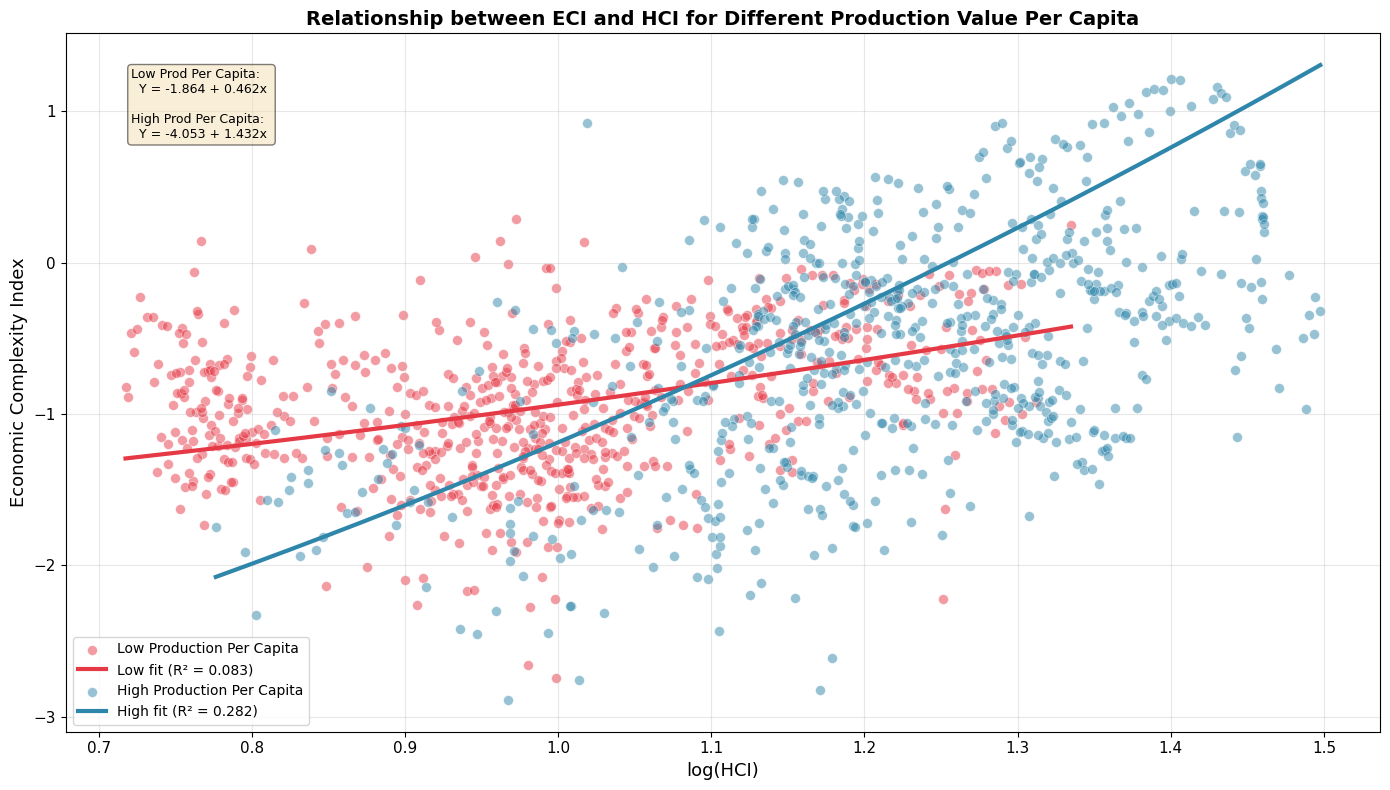


GROUP STATISTICS
\Median Production Per Capita threshold: 196.96
Low Production Per Capita observations: 675
High Production Per Capita observations: 675

LOW PRODUCTION PER CAPITA GROUP - QUADRATIC FIT

Equation: log(ECI) = -1.8639 + 0.4623

R-squared: 0.0828
Adjusted R-squared: 0.0814

Coefficients:
  Intercept: -1.8639 (p-value: 0.0000)
  Linear term: 0.4623 (p-value: 0.0000)

HIGH PRODUCTION PER CAPITA GROUP - QUADRATIC FIT

Equation: log(ECI) = -4.0526 + 1.4322

R-squared: 0.2823
Adjusted R-squared: 0.2812

Coefficients:
  Intercept: -4.0526 (p-value: 0.0000)
  Linear term: 1.4322 (p-value: 0.0000)

Linear term (slope at origin):
  Low Prod Per Capita:  0.4623
  High Prod Per Capita: 1.4322
  Difference: 0.9699


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Create dummy variable for high/low production per capita
median_prod_per_capita = high_resource_countries_df['Total_Production_Value_Per_Capita'].median()
high_resource_countries_df['High_Prod_Per_Capita'] = (
    high_resource_countries_df['Total_Production_Value_Per_Capita'] > median_prod_per_capita
).astype(int)


x = high_resource_countries_df['log_HCI'].values
y = high_resource_countries_df['Economic Complexity Index'].values
groups = high_resource_countries_df['High_Prod_Per_Capita'].values

# Remove any NaN values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(groups)
x_clean = x[mask]
y_clean = y[mask]
groups_clean = groups[mask]

# Separate data by group
x_low = x_clean[groups_clean == 0]
y_low = y_clean[groups_clean == 0]
x_high = x_clean[groups_clean == 1]
y_high = y_clean[groups_clean == 1]

# Fit quadratic models for each group
def fit_line(x_data, y_data):
    x_squared = x_data
    X_quad = np.column_stack([x_data, x_squared])
    X_quad = sm.add_constant(X_quad)
    model = sm.OLS(y_data, X_quad)
    return model.fit()

results_low = fit_line(x_low, y_low)
results_high = fit_line(x_high, y_high)

# Generate smooth lines for plotting
x_range_low = np.linspace(x_low.min(), x_low.max(), 300)
x_range_high = np.linspace(x_high.min(), x_high.max(), 300)

def predict_line(x_range, results):
    x_range_squared = x_range ** 2
    X_range = np.column_stack([np.ones_like(x_range), x_range, x_range_squared])
    return results.predict(X_range)

y_pred_low = predict_line(x_range_low, results_low)
y_pred_high = predict_line(x_range_high, results_high)

# Create the plot
plt.figure(figsize=(14, 8))

# Plot low production per capita group
plt.scatter(x_low, y_low, alpha=0.5, s=50, color='#E63946', 
            edgecolors='white', linewidth=0.5, label='Low Production Per Capita')
plt.plot(x_range_low, y_pred_low, color='#E63946', linewidth=3, linestyle='-',
         label=f'Low fit (R² = {results_low.rsquared:.3f})')

# Plot high production per capita group
plt.scatter(x_high, y_high, alpha=0.5, s=50, color='#2E86AB', 
            edgecolors='white', linewidth=0.5, label='High Production Per Capita')
plt.plot(x_range_high, y_pred_high, color='#2E86AB', linewidth=3, linestyle='-',
         label=f'High fit (R² = {results_high.rsquared:.3f})')

plt.xlabel('log(HCI)', fontsize=13)
plt.ylabel('Economic Complexity Index', fontsize=13)
plt.title('Relationship between ECI and HCI for Different Production Value Per Capita', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=11)

# Add equations text
low_intercept = results_low.params[0]
low_linear = results_low.params[1]

high_intercept = results_high.params[0]
high_linear = results_high.params[1]

equation_text = (
    f'Low Prod Per Capita:\n'
    f'  Y = {low_intercept:.3f} + {low_linear:.3f}x \n\n'
    f'High Prod Per Capita:\n'
    f'  Y = {high_intercept:.3f} + {high_linear:.3f}x'
)
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("GROUP STATISTICS")
print("="*80)
print(f"\Median Production Per Capita threshold: {median_prod_per_capita:.2f}")
print(f"Low Production Per Capita observations: {len(x_low)}")
print(f"High Production Per Capita observations: {len(x_high)}")

print("\n" + "="*80)
print("LOW PRODUCTION PER CAPITA GROUP - QUADRATIC FIT")
print("="*80)
print(f"\nEquation: log(ECI) = {low_intercept:.4f} + {low_linear:.4f}")
print(f"\nR-squared: {results_low.rsquared:.4f}")
print(f"Adjusted R-squared: {results_low.rsquared_adj:.4f}")
print(f"\nCoefficients:")
print(f"  Intercept: {low_intercept:.4f} (p-value: {results_low.pvalues[0]:.4f})")
print(f"  Linear term: {low_linear:.4f} (p-value: {results_low.pvalues[1]:.4f})")

print("\n" + "="*80)
print("HIGH PRODUCTION PER CAPITA GROUP - QUADRATIC FIT")
print("="*80)
print(f"\nEquation: log(ECI) = {high_intercept:.4f} + {high_linear:.4f}")
print(f"\nR-squared: {results_high.rsquared:.4f}")
print(f"Adjusted R-squared: {results_high.rsquared_adj:.4f}")
print(f"\nCoefficients:")
print(f"  Intercept: {high_intercept:.4f} (p-value: {results_high.pvalues[0]:.4f})")
print(f"  Linear term: {high_linear:.4f} (p-value: {results_high.pvalues[1]:.4f})")


print("="*80)

# Display comparison

print(f"\nLinear term (slope at origin):")
print(f"  Low Prod Per Capita:  {low_linear:.4f}")
print(f"  High Prod Per Capita: {high_linear:.4f}")
print(f"  Difference: {high_linear - low_linear:.4f}")

print("="*80)

In [32]:
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure()

# Add scatter plot for low production per capita group
fig.add_trace(go.Scatter(
    x=x_low,
    y=y_low,
    mode='markers',
    name='Low Production Per Capita',
    marker=dict(
        size=8,
        color='#E63946',
        opacity=0.5,
        line=dict(color='white', width=0.5)
    ),
    hovertemplate='<b>Low Prod Per Capita</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add quadratic fit line for low production
fig.add_trace(go.Scatter(
    x=x_range_low,
    y=y_pred_low,
    mode='lines',
    name=f'Low fit (R² = {results_low.rsquared:.3f})',
    line=dict(color='#E63946', width=3),
    hovertemplate='<b>Low Fit</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'Predicted log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add scatter plot for high production per capita group
fig.add_trace(go.Scatter(
    x=x_high,
    y=y_high,
    mode='markers',
    name='High Production Per Capita',
    marker=dict(
        size=8,
        color='#2E86AB',
        opacity=0.5,
        line=dict(color='white', width=0.5)
    ),
    hovertemplate='<b>High Prod Per Capita</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Add quadratic fit line for high production
fig.add_trace(go.Scatter(
    x=x_range_high,
    y=y_pred_high,
    mode='lines',
    name=f'High fit (R² = {results_high.rsquared:.3f})',
    line=dict(color='#2E86AB', width=3),
    hovertemplate='<b>High Fit</b><br>' +
                  'Interaction: %{x:.4f}<br>' +
                  'Predicted log(ECI): %{y:.4f}<br>' +
                  '<extra></extra>'
))

# Update layout
fig.update_layout(
    title=dict(
        text='Relationship between ECI and HCI for Different Production Value Per Capita',
        font=dict(size=16, family='Arial, sans-serif', color='#333333')
    ),
    xaxis=dict(
        title=dict(
            text='log(HCI)',
            font=dict(size=14)
        ),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128, 128, 128, 0.3)'
    ),
    yaxis=dict(
        title=dict(
            text='Economic Complexity Index',
            font=dict(size=14)
        ),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128, 128, 128, 0.3)'
    ),
    width=1000,
    height=600,
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='rgba(0, 0, 0, 0.2)',
        borderwidth=1
    )
)

# Export to HTML
fig.write_html('eci_hci_production_interaction.html')
print("Plot exported to 'eci_hci_production_interaction.html'")

# Optional: Show the plot
fig.show()

Plot exported to 'eci_hci_production_interaction.html'


## Model with only lagged variable

In [42]:
import statsmodels.api as sm
import pandas as pd
import numpy as np


# Create a clean dataset
regression_data = high_resource_countries_df[['log_ECI', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop any rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# Create lagged log_ECI
regression_data['log_ECI_lag1'] = regression_data.groupby('Country Code')['log_ECI'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data = regression_data.dropna(subset=['log_ECI_lag1'])


# Define y and X (NO country dummies)
y = regression_data['log_ECI']
X = regression_data['log_ECI_lag1']

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'log_ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['log_ECI_lag1']
    lag_pval = results_one_lag.pvalues['log_ECI_lag1']
    print(f"log_ECI(t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1% higher ECI last year predicts {lag_coef:.2%} higher ECI this year")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Log-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The elasticity of ECI with respect to HCI INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to HCI DECREASES with resource production")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The elasticity of ECI with respect to investment INCREASES with resource production")
        else:
            print("  → The elasticity of ECI with respect to investment DECREASES with resource production")

                            OLS Regression Results                            
Dep. Variable:                log_ECI   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     494.5
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.53e-28
Time:                        18:06:43   Log-Likelihood:                 876.66
No. Observations:                1296   AIC:                            -1749.
Df Residuals:                    1294   BIC:                            -1739.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1874      0.039      4.785   

 Adj. R-squared: 0.698. In model 3, Adj. R-squared is 0.712. Adj R-squared increased marginally. 

## No log variables (better for effect on ECI interpretation)

In [33]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset — using ECI (levels) instead of log_ECI
regression_data_levels = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data_levels[var] = pd.to_numeric(regression_data_levels[var], errors='coerce')

# Drop any rows with missing values
regression_data_levels = regression_data_levels.dropna()

# Mean-center the logged variables before creating interactions
regression_data_levels['log_HCI_centered'] = regression_data_levels['log_HCI'] - regression_data_levels['log_HCI'].mean()
regression_data_levels['log_GFCF_centered'] = regression_data_levels['log_GFCF'] - regression_data_levels['log_GFCF'].mean()
regression_data_levels['log_Production_centered'] = regression_data_levels['log_Production_Value'] - regression_data_levels['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data_levels['log_HCI_x_log_Production'] = regression_data_levels['log_HCI_centered'] * regression_data_levels['log_Production_centered']
regression_data_levels['log_GFCF_x_log_Production'] = regression_data_levels['log_GFCF_centered'] * regression_data_levels['log_Production_centered']

# Add interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y (ECI in levels) and X
y = regression_data_levels['Economic Complexity Index']
X = regression_data_levels[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors by country
model = sm.OLS(y, X)
results_levels = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data_levels['Country Code']})

# Display results
print(results_levels.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_levels.params.index:
        coef = results_levels.params[var]
        se = results_levels.bse[var]
        tstat = results_levels.tvalues[var]
        pval = results_levels.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_levels.rsquared:.4f}")
print(f"Adjusted R-squared: {results_levels.rsquared_adj:.4f}")
print(f"N observations: {results_levels.nobs:.0f}")
print(f"N countries: {regression_data_levels['Country Code'].nunique()}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Level-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_levels.params.index:
    hci_int_coef = results_levels.params['log_HCI_x_log_Production']
    hci_int_pval = results_levels.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with HCI")
        else:
            print("  → The effect of resource production on ECI DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_levels.params.index:
    gcf_int_coef = results_levels.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_levels.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with investment")
        else:
            print("  → The effect of resource production on ECI DECREASES with investment")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.360
Model:                                   OLS   Adj. R-squared:                  0.356
Method:                        Least Squares   F-statistic:                     8.504
Date:                       Thu, 12 Mar 2026   Prob (F-statistic):           2.34e-07
Time:                               13:04:01   Log-Likelihood:                -1073.2
No. Observations:                       1350   AIC:                             2164.
Df Residuals:                           1341   BIC:                             2211.
Df Model:                                  8                                         
Covariance Type:                     cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

## One Lag

In [34]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data_one_lag = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data_one_lag[var] = pd.to_numeric(regression_data_one_lag[var], errors='coerce')

# Drop any rows with missing values
regression_data_one_lag = regression_data_one_lag.dropna()

# Sort by country and year to ensure proper lagging
regression_data_one_lag = regression_data_one_lag.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data_one_lag['ECI_lag1'] = regression_data_one_lag.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data_one_lag = regression_data_one_lag.dropna(subset=['ECI_lag1'])

# Mean-center the logged variables before creating interactions
regression_data_one_lag['log_HCI_centered'] = regression_data_one_lag['log_HCI'] - regression_data_one_lag['log_HCI'].mean()
regression_data_one_lag['log_GFCF_centered'] = regression_data_one_lag['log_GFCF'] - regression_data_one_lag['log_GFCF'].mean()
regression_data_one_lag['log_Production_centered'] = regression_data_one_lag['log_Production_Value'] - regression_data_one_lag['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data_one_lag['log_HCI_x_log_Production'] = regression_data_one_lag['log_HCI_centered'] * regression_data_one_lag['log_Production_centered']
regression_data_one_lag['log_GFCF_x_log_Production'] = regression_data_one_lag['log_GFCF_centered'] * regression_data_one_lag['log_Production_centered']

# Add lagged ECI and interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data_one_lag['Economic Complexity Index']
X = regression_data_one_lag[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data_one_lag['Country Code']})

# Display results
print(results_one_lag.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag.params.index:
        coef = results_one_lag.params[var]
        se = results_one_lag.bse[var]
        tstat = results_one_lag.tvalues[var]
        pval = results_one_lag.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag.nobs:.0f}")
print(f"N countries: {regression_data_one_lag['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data_one_lag) / regression_data_one_lag['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation of lagged dependent variable
print("\n" + "="*80)
print("LAGGED DEPENDENT VARIABLE INTERPRETATION")
print("="*80)
if 'ECI_lag1' in results_one_lag.params.index:
    lag_coef = results_one_lag.params['ECI_lag1']
    lag_pval = results_one_lag.pvalues['ECI_lag1']
    print(f"Economic Complexity Index (t-1): {lag_coef:.4f} (p={lag_pval:.4f})")
    print(f"  → Persistence/autocorrelation in economic complexity")
    print(f"  → A 1-unit higher ECI last year predicts a {lag_coef:.4f} higher ECI this year")

# Interpretation of interaction terms
print("\n" + "="*80)
print("INTERACTION TERM INTERPRETATION (Level-Log Model)")
print("="*80)
if 'log_HCI_x_log_Production' in results_one_lag.params.index:
    hci_int_coef = results_one_lag.params['log_HCI_x_log_Production']
    hci_int_pval = results_one_lag.pvalues['log_HCI_x_log_Production']
    print(f"\nlog(HCI) × log(Production): {hci_int_coef:.4f} (p={hci_int_pval:.4f})")
    if hci_int_pval < 0.05:
        if hci_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with HCI")
        else:
            print("  → The effect of resource production on ECI DECREASES with HCI")

if 'log_GFCF_x_log_Production' in results_one_lag.params.index:
    gcf_int_coef = results_one_lag.params['log_GFCF_x_log_Production']
    gcf_int_pval = results_one_lag.pvalues['log_GFCF_x_log_Production']
    print(f"\nlog(GFCF) × log(Production): {gcf_int_coef:.4f} (p={gcf_int_pval:.4f})")
    if gcf_int_pval < 0.05:
        if gcf_int_coef > 0:
            print("  → The effect of resource production on ECI INCREASES with investment")
        else:
            print("  → The effect of resource production on ECI DECREASES with investment")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.780
Model:                                   OLS   Adj. R-squared:                  0.778
Method:                        Least Squares   F-statistic:                     360.4
Date:                       Thu, 12 Mar 2026   Prob (F-statistic):           3.01e-44
Time:                               13:04:12   Log-Likelihood:                -339.19
No. Observations:                       1296   AIC:                             698.4
Df Residuals:                           1286   BIC:                             750.0
Df Model:                                  9                                         
Covariance Type:                     cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

## All variables lagged

In [35]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)'
]

# Create a clean dataset
regression_data_lags = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data_lags[var] = pd.to_numeric(regression_data_lags[var], errors='coerce')

# Drop any rows with missing values
regression_data_lags = regression_data_lags.dropna()

# Sort by country and year to ensure proper lagging
regression_data_lags = regression_data_lags.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data_lags['ECI_lag1'] = regression_data_lags.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Create lagged versions of all independent variables
lagged_vars = []
for var in independent_vars:
    lagged_name = f'{var}_lag1'
    regression_data_lags[lagged_name] = regression_data_lags.groupby('Country Code')[var].shift(1)
    lagged_vars.append(lagged_name)

# Add lagged ECI to the list
lagged_vars_with_eci = lagged_vars + ['ECI_lag1']

# Drop rows where any lagged variable is missing (first year for each country)
regression_data_lags = regression_data_lags.dropna(subset=lagged_vars_with_eci)

# Mean-center the LAGGED logged variables before creating interactions
regression_data_lags['log_HCI_lag1_centered'] = regression_data_lags['log_HCI_lag1'] - regression_data_lags['log_HCI_lag1'].mean()
regression_data_lags['log_GFCF_lag1_centered'] = regression_data_lags['log_GFCF_lag1'] - regression_data_lags['log_GFCF_lag1'].mean()
regression_data_lags['log_Production_lag1_centered'] = regression_data_lags['log_Production_Value_lag1'] - regression_data_lags['log_Production_Value_lag1'].mean()

# Create interaction terms from centered LAGGED variables
regression_data_lags['log_HCI_x_log_Production_lag1'] = regression_data_lags['log_HCI_lag1_centered'] * regression_data_lags['log_Production_lag1_centered']
regression_data_lags['log_GFCF_x_log_Production_lag1'] = regression_data_lags['log_GFCF_lag1_centered'] * regression_data_lags['log_Production_lag1_centered']

# Add interaction terms to lagged variables list
lagged_vars_with_interactions = lagged_vars_with_eci + [
    'log_HCI_x_log_Production_lag1',
    'log_GFCF_x_log_Production_lag1'
]

# Define y and X
y = regression_data_lags['Economic Complexity Index']
X = regression_data_lags[lagged_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_lags = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data_lags['Country Code']})

# Display results
print(results_lags.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (All Lagged, Clustered SE by Country)")
print("="*80)
for var in lagged_vars_with_interactions + ['const']:
    if var in results_lags.params.index:
        coef = results_lags.params[var]
        se = results_lags.bse[var]
        tstat = results_lags.tvalues[var]
        pval = results_lags.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)').replace('_lag1', ' (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_lags.rsquared:.4f}")
print(f"Adjusted R-squared: {results_lags.rsquared_adj:.4f}")
print(f"N observations: {results_lags.nobs:.0f}")
print(f"N countries: {regression_data_lags['Country Code'].nunique()}")
print(f"Observations per country: {len(regression_data_lags) / regression_data_lags['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")

# Interpretation
print("\n" + "="*80)
print("MODEL INTERPRETATION")
print("="*80)
print("All independent variables are lagged by one period (t-1)")
print("This specification helps address:")
print("  - Endogeneity concerns (X(t-1) predetermined relative to Y(t))")
print("  - Reverse causality (past values can't be caused by current outcomes)")
print("  - Dynamic effects (how past conditions influence current complexity)")

if 'ECI_lag1' in results_lags.params.index:
    lag_coef = results_lags.params['ECI_lag1']
    print(f"\nPersistence coefficient: {lag_coef:.4f}")
    print(f"  → A 1-unit higher ECI last year predicts a {lag_coef:.4f} higher ECI this year")

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.779
Model:                                   OLS   Adj. R-squared:                  0.778
Method:                        Least Squares   F-statistic:                     326.7
Date:                       Thu, 12 Mar 2026   Prob (F-statistic):           3.87e-43
Time:                               13:04:22   Log-Likelihood:                -341.23
No. Observations:                       1296   AIC:                             702.5
Df Residuals:                           1286   BIC:                             754.1
Df Model:                                  9                                         
Covariance Type:                     cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

Export all lagged regression to HTML table

In [49]:
import numpy as np

# ── Variable display names & ordering ─────────────────────────────────────────
var_labels = {
    'log_HCI_lag1':                          'Human Capital Index (log)',
    'log_GFCF_lag1':                         'Gross Fixed Capital Formation (log)',
    'log_Production_Value_lag1':             'Production Value (log)',
    'Political stability — estimate_lag1':   'Political Stability',
    'Rule of law index_lag1':                'Rule of Law',
    'Trade (% of GDP)_lag1':                 'Trade Openness (% GDP)',
    'log_HCI_x_log_Production_lag1':         'HCI \u00d7 Production (log)',
    'log_GFCF_x_log_Production_lag1':        'GFCF \u00d7 Production (log)',
    'ECI_lag1':                              'Economic Complexity Index (t\u22121)',
    'const':                                 'Constant',
}

var_order = [
    'log_HCI_lag1',
    'log_GFCF_lag1',
    'log_Production_Value_lag1',
    'Political stability — estimate_lag1',
    'Rule of law index_lag1',
    'Trade (% of GDP)_lag1',
    'log_HCI_x_log_Production_lag1',
    'log_GFCF_x_log_Production_lag1',
    'ECI_lag1',
    'const',
]

section_before = {
    'log_HCI_x_log_Production_lag1': 'Interaction terms',
    'ECI_lag1':                      'Lagged dependent variable',
    'const':                         None,
}

# ── Helpers ────────────────────────────────────────────────────────────────────
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def extract(res, var):
    if var not in res.params.index:
        return None, None
    c, s, p = res.params[var], res.bse[var], res.pvalues[var]
    return f'{c:.3f}{stars(p)}', f'({s:.3f})'

# ── HTML builder ───────────────────────────────────────────────────────────────
def build_html(res, regression_data):
    css = """
    <style>
      body  { font-family: "Times New Roman", Times, serif; font-size: 13px;
              margin: 40px; color: #000; }
      h2    { font-size: 14px; font-weight: normal; text-align: center;
              margin-bottom: 4px; }
      table { border-collapse: collapse; width: 480px; margin: 0 auto; }
      th, td { padding: 3px 10px; text-align: center; }
      td.varname { text-align: left; padding-left: 4px; min-width: 240px; }
      tr.se-row td { padding-top: 0; padding-bottom: 4px; }
      .top-border { border-top: 2px solid #000; }
      .mid-border { border-top: 1px solid #000; }
      .bot-border { border-bottom: 2px solid #000; }
      .section-lbl td { font-style: italic; font-size: 11px;
                        padding-top: 6px; color: #444; text-align: left;
                        padding-left: 4px; }
      .note { font-size: 11px; text-align: left; width: 480px; margin: 4px auto 0; }
      sup { font-size: 9px; }
    </style>
    """

    header = """
    <thead>
      <tr class="top-border">
        <th></th>
        <th><em>Dependent variable: Economic Complexity Index</em></th>
      </tr>
      <tr class="mid-border bot-border">
        <th></th><th>(1)</th>
      </tr>
    </thead>"""

    body = ''
    for v in var_order:
        if v in section_before:
            lbl = section_before[v]
            if lbl:
                body += f'<tr class="section-lbl mid-border"><td colspan="2">{lbl}</td></tr>\n'
            else:
                body += '<tr class="mid-border"><td colspan="2"></td></tr>\n'

        c, s = extract(res, v)
        if not c:
            continue
        lbl = var_labels.get(v, v)
        body += f'<tr><td class="varname">{lbl}</td><td>{c}</td></tr>\n'
        body += f'<tr class="se-row"><td></td><td>{s}</td></tr>\n'

    n_obs      = int(res.nobs)
    n_countries = regression_data['Country Code'].nunique()

    footer = f"""
    <tr class="mid-border">
      <td class="varname">Observations</td><td>{n_obs:,}</td>
    </tr>
    <tr>
      <td class="varname">Countries</td><td>{n_countries}</td>
    </tr>
    <tr>
      <td class="varname">R<sup>2</sup></td><td>{res.rsquared:.3f}</td>
    </tr>
    <tr>
      <td class="varname">Adjusted R<sup>2</sup></td><td>{res.rsquared_adj:.3f}</td>
    </tr>
    <tr class="bot-border">
      <td class="varname">Clustered SE</td><td>Country</td>
    </tr>"""

    note = (
        '<p class="note"><em>Note:</em>&nbsp;'
        '<sup>*</sup>p&lt;0.1;&nbsp;<sup>**</sup>p&lt;0.05;&nbsp;'
        '<sup>***</sup>p&lt;0.01.&nbsp;'
        'Clustered standard errors by country in parentheses.&nbsp;'
        'All regressors lagged one period (t&#8722;1) to address endogeneity and reverse causality.&nbsp;'
        'Interaction terms computed on mean-centered lagged logged variables.</p>'
    )

    return f"""<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8">{css}</head>
<body>
<h2>Economic Complexity in Resource-Rich Countries — All-Lagged Specification</h2>
<table>{header}<tbody>{body}{footer}</tbody></table>
{note}
</body></html>"""

# ── Save ───────────────────────────────────────────────────────────────────────
html_out = build_html(results_lags, regression_data_lags)

with open('regression_table_m4.html', 'w', encoding='utf-8') as f:
    f.write(html_out)

print("Saved → regression_table_m4.html")

Saved → regression_table_m4.html


## Correlation ECI manufacturing value added

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [37]:
corr_data = high_resource_countries_df[['Economic Complexity Index', 'Manufacturing', 'Country Code', 'Year']].copy()
corr_data['Economic Complexity Index'] = pd.to_numeric(corr_data['Economic Complexity Index'], errors='coerce')
corr_data['Manufacturing'] = pd.to_numeric(corr_data['Manufacturing'], errors='coerce')
corr_data = corr_data.dropna(subset=['Economic Complexity Index', 'Manufacturing'])

# --- Summary statistics ---
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(corr_data[['Economic Complexity Index', 'Manufacturing']].describe().round(4))

# --- Correlation coefficients ---
pearson_r, pearson_p = stats.pearsonr(corr_data['Economic Complexity Index'], corr_data['Manufacturing'])
spearman_r, spearman_p = stats.spearmanr(corr_data['Economic Complexity Index'], corr_data['Manufacturing'])

print("\n" + "="*60)
print("CORRELATION RESULTS")
print("="*60)
print(f"Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.4f}{'***' if pearson_p < 0.01 else '**' if pearson_p < 0.05 else '*' if pearson_p < 0.10 else ''})")
print(f"Spearman ρ = {spearman_r:.4f}  (p = {spearman_p:.4f}{'***' if spearman_p < 0.01 else '**' if spearman_p < 0.05 else '*' if spearman_p < 0.10 else ''})")
print(f"\nN observations : {len(corr_data)}")
print(f"N countries    : {corr_data['Country Code'].nunique()}")

SUMMARY STATISTICS
       Economic Complexity Index  Manufacturing
count                  1350.0000      1350.0000
mean                     -0.7600        11.4560
std                       0.6698         6.0741
min                      -2.8900         0.6522
25%                      -1.2197         7.4579
50%                      -0.8035        10.2082
75%                      -0.3430        14.8802
max                       1.2110        44.9804

CORRELATION RESULTS
Pearson  r = 0.3271  (p = 0.0000***)
Spearman ρ = 0.3232  (p = 0.0000***)

N observations : 1350
N countries    : 54


ECI and Manufacturing are reasonably correlated

## Add Technology, Population and resource type controls (only used access to electricity because of high correlation). In resource type dummies the base is precious metals dominant

In [38]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)',
    # Resource type dummies
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    # Additional controls
    'Access to electricity (% of population)'
]

# Create a clean dataset
regression_data_one_lag_add_controls = high_resource_countries_df[['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data_one_lag_add_controls[var] = pd.to_numeric(regression_data_one_lag_add_controls[var], errors='coerce')

# Log-transform Population (scale adjustment)
#regression_data['log_Population'] = np.log(regression_data['Population'])
#regression_data = regression_data.drop(columns=['Population'])

# Update independent_vars to reflect the transformation
#independent_vars = [v for v in independent_vars if v != 'Population'] + ['log_Population']

# Drop any rows with missing values
regression_data_one_lag_add_controls = regression_data_one_lag_add_controls.dropna()

# Sort by country and year to ensure proper lagging
regression_data_one_lag_add_controls = regression_data_one_lag_add_controls.sort_values(['Country Code', 'Year'])

# Create lagged Economic Complexity Index
regression_data_one_lag_add_controls['ECI_lag1'] = regression_data_one_lag_add_controls.groupby('Country Code')['Economic Complexity Index'].shift(1)

# Drop rows where lagged ECI is missing (first year for each country)
regression_data_one_lag_add_controls = regression_data_one_lag_add_controls.dropna(subset=['ECI_lag1'])

# Mean-center the logged variables before creating interactions
regression_data_one_lag_add_controls['log_HCI_centered'] = regression_data_one_lag_add_controls['log_HCI'] - regression_data_one_lag_add_controls['log_HCI'].mean()
regression_data_one_lag_add_controls['log_GFCF_centered'] = regression_data_one_lag_add_controls['log_GFCF'] - regression_data_one_lag_add_controls['log_GFCF'].mean()
regression_data_one_lag_add_controls['log_Production_centered'] = regression_data_one_lag_add_controls['log_Production_Value'] - regression_data_one_lag_add_controls['log_Production_Value'].mean()

# Create interaction terms from centered logged variables
regression_data_one_lag_add_controls['log_HCI_x_log_Production'] = regression_data_one_lag_add_controls['log_HCI_centered'] * regression_data_one_lag_add_controls['log_Production_centered']
regression_data_one_lag_add_controls['log_GFCF_x_log_Production'] = regression_data_one_lag_add_controls['log_GFCF_centered'] * regression_data_one_lag_add_controls['log_Production_centered']

# Add lagged ECI and interaction terms to independent variables list
independent_vars_with_interactions = independent_vars + [
    'ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y and X (NO country dummies)
y = regression_data_one_lag_add_controls['Economic Complexity Index']
X = regression_data_one_lag_add_controls[independent_vars_with_interactions]

# Add constant
X = sm.add_constant(X)

# Run OLS with clustered standard errors BY COUNTRY
model = sm.OLS(y, X)
results_one_lag_add_controls = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data_one_lag_add_controls['Country Code']})

# Display results
print(results_one_lag_add_controls.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (Lagged ECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results_one_lag_add_controls.params.index:
        coef = results_one_lag_add_controls.params[var]
        se = results_one_lag_add_controls.bse[var]
        tstat = results_one_lag_add_controls.tvalues[var]
        pval = results_one_lag_add_controls.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'Economic Complexity Index (t-1)')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared: {results_one_lag_add_controls.rsquared:.4f}")
print(f"Adjusted R-squared: {results_one_lag_add_controls.rsquared_adj:.4f}")
print(f"N observations: {results_one_lag_add_controls.nobs:.0f}")
print(f"Observations per country: {len(regression_data_one_lag_add_controls) / regression_data_one_lag_add_controls['Country Code'].nunique():.1f}")
print(f"Condition number: {np.linalg.cond(X):.2e}")


            

                                OLS Regression Results                               
Dep. Variable:     Economic Complexity Index   R-squared:                       0.784
Model:                                   OLS   Adj. R-squared:                  0.782
Method:                        Least Squares   F-statistic:                     242.1
Date:                       Thu, 12 Mar 2026   Prob (F-statistic):           2.56e-42
Time:                               13:05:40   Log-Likelihood:                -326.69
No. Observations:                       1296   AIC:                             681.4
Df Residuals:                           1282   BIC:                             753.7
Df Model:                                 13                                         
Covariance Type:                     cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

Access to electricity is a main driver. Intrestingly, GFCF is now signifiant and HCI is not. Subsoil metals perform worse among the 3 type of resources

export base, one lag and extra controls regression to HTML table

In [51]:
import numpy as np

# ── Variable display names & ordering ─────────────────────────────────────────
var_labels = {
    'log_HCI':                      'Human Capital Index (log)',
    'log_GFCF':                     'Gross Fixed Capital Formation (log)',
    'log_Production_Value':         'Production Value (log)',
    'Political stability — estimate': 'Political Stability',
    'Rule of law index':            'Rule of Law',
    'Trade (% of GDP)':             'Trade Openness (% GDP)',
    'Hydrocarbons_Dominant':        'Hydrocarbons Dominant',
    'Subsoil_Metals_Dominant':      'Subsoil Metals Dominant',
    'Precious_Metals_Dominant':     'Precious Metals Dominant',
    'Access to electricity (% of population)': 'Access to Electricity (%)',
    'log_HCI_x_log_Production':     'HCI \u00d7 Production (log)',
    'log_GFCF_x_log_Production':    'GFCF \u00d7 Production (log)',
    'ECI_lag1':                     'Economic Complexity Index (t\u22121)',
    'const':                        'Constant',
}

# Order rows appear in the table (const goes last)
var_order = [
    'log_HCI',
    'log_GFCF',
    'log_Production_Value',
    'Political stability — estimate',
    'Rule of law index',
    'Trade (% of GDP)',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Access to electricity (% of population)',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production',
    'ECI_lag1',
    'const',
]

# ── Significance stars ─────────────────────────────────────────────────────────
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

# ── Pull results from a fitted statsmodels result object ──────────────────────
def extract(res, var):
    """Return (coef_str, se_str) or (None, None) if variable not in model."""
    if var not in res.params.index:
        return None, None
    c = res.params[var]
    s = res.bse[var]
    p = res.pvalues[var]
    return f'{c:.3f}{stars(p)}', f'({s:.3f})'

# ── Models list  (results_levels = model 1, results_one_lag = model 2/3) ──────
# Rename your result objects here if needed:
models      = [results_levels, results_one_lag, results_one_lag_add_controls]
model_names = ['(1)', '(2)', '(3)']

# results_one_lag_base  →  the object from doc 4 (lag, no dummies)
# results_one_lag       →  the object from doc 5 (lag + dummies + electricity)

# ── HTML builder ──────────────────────────────────────────────────────────────
def build_html(models, model_names, var_order, var_labels, regression_data_list):
    """
    regression_data_list : list of the regression_data DataFrames used for each model
                           (needed for N countries)
    """
    n_models = len(models)
    css = """
    <style>
      body  { font-family: "Times New Roman", Times, serif; font-size: 13px;
              margin: 40px; color: #000; }
      h2    { font-size: 14px; font-weight: normal; text-align: center;
              margin-bottom: 4px; }
      table { border-collapse: collapse; width: 560px; margin: 0 auto; }
      th, td { padding: 3px 10px; text-align: center; }
      td.varname { text-align: left; padding-left: 4px; min-width: 220px; }
      tr.se-row td { padding-top: 0; padding-bottom: 4px; color: #000; }
      .top-border { border-top: 2px solid #000; }
      .mid-border { border-top: 1px solid #000; }
      .bot-border { border-bottom: 2px solid #000; }
      .note { font-size: 11px; text-align: left; width: 560px;
              margin: 4px auto 0; }
      .section-header td { font-style: italic; font-size: 11px;
                           padding-top: 6px; color: #444; }
      sup { font-size: 9px; }
    </style>
    """

    # ── Header ─────────────────────────────────────────────────────────────────
    col_heads = ''.join(f'<th>{m}</th>' for m in model_names)
    header = f"""
    <thead>
      <tr class="top-border">
        <th></th>
        <th colspan="{n_models}"><em>Dependent variable: Economic Complexity Index</em></th>
      </tr>
      <tr class="mid-border bot-border">
        <th></th>{col_heads}
      </tr>
    </thead>"""

    # ── Body rows ──────────────────────────────────────────────────────────────
    # Section breaks
    section_before = {
        'Hydrocarbons_Dominant':    'Resource type dummies',
        'log_HCI_x_log_Production': 'Interaction terms',
        'ECI_lag1':                 'Lagged dependent variable',
        'const':                    '',
    }

    body = ''
    for v in var_order:
        # Section label row
        if v in section_before:
            label = section_before[v]
            sep_border = 'class="mid-border"' if label else 'class="mid-border"'
            if label:
                body += f'<tr class="section-header"><td class="varname" colspan="{n_models+1}">{label}</td></tr>\n'
            else:
                body += f'<tr class="mid-border"><td colspan="{n_models+1}"></td></tr>\n'

        coef_cells = ''
        se_cells   = ''
        any_model  = False
        for res in models:
            c, s = extract(res, v)
            if c is not None:
                any_model = True
            coef_cells += f'<td>{c if c else ""}</td>'
            se_cells   += f'<td>{s if s else ""}</td>'

        if not any_model:
            continue   # skip variables not present in any model

        lbl = var_labels.get(v, v)
        body += f'<tr><td class="varname">{lbl}</td>{coef_cells}</tr>\n'
        body += f'<tr class="se-row"><td></td>{se_cells}</tr>\n'

    # ── Footer stats ───────────────────────────────────────────────────────────
    def fc(val): return f'{val:,.0f}' if val == int(val) else f'{val:.3f}'

    footer = '<tr class="mid-border">\n'
    footer += '<td class="varname">Observations</td>'
    footer += ''.join(f'<td>{int(m.nobs):,}</td>' for m in models)
    footer += '</tr>\n'

    footer += '<tr>\n<td class="varname">Countries</td>'
    footer += ''.join(f'<td>{rd["Country Code"].nunique()}</td>' for rd in regression_data_list)
    footer += '</tr>\n'

    footer += '<tr>\n<td class="varname">R<sup>2</sup></td>'
    footer += ''.join(f'<td>{m.rsquared:.3f}</td>' for m in models)
    footer += '</tr>\n'

    footer += '<tr>\n<td class="varname">Adjusted R<sup>2</sup></td>'
    footer += ''.join(f'<td>{m.rsquared_adj:.3f}</td>' for m in models)
    footer += '</tr>\n'

    footer += '<tr class="bot-border">\n<td class="varname">Clustered SE</td>'
    footer += f'<td colspan="{n_models}">Country</td>'
    footer += '</tr>\n'

    note = (
        '<p class="note"><em>Note:</em>&nbsp; '
        '<sup>*</sup>p&lt;0.1;&nbsp; <sup>**</sup>p&lt;0.05;&nbsp; '
        '<sup>***</sup>p&lt;0.01. &nbsp;'
        'Clustered standard errors by country in parentheses. &nbsp;'
        'Interaction terms computed on mean-centered logged variables. &nbsp;'
        'Model (1): no lagged dependent variable. &nbsp;'
        'Models (2)–(3): include ECI(t&#8722;1). &nbsp;'
        'Model (3): additionally controls for resource-type dummies and '
        'access to electricity.</p>'
    )

    html = f"""<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8">{css}</head>
<body>
<h2>Economic Complexity in Resource-Rich Countries</h2>
<table>
  {header}
  <tbody>
  {body}
  {footer}
  </tbody>
</table>
{note}
</body>
</html>"""
    return html

# ── Run & save ─────────────────────────────────────────────────────────────────
# Pass the three regression_data DataFrames in the same order as models
html_out = build_html(
    models             = [results_levels, results_one_lag, results_one_lag_add_controls],
    model_names        = ['(1)', '(2)', '(3)'],
    var_order          = var_order,
    var_labels         = var_labels,
    regression_data_list = [regression_data, regression_data_one_lag, regression_data_one_lag_add_controls],
)

with open('regression_table.html', 'w', encoding='utf-8') as f:
    f.write(html_out)

print("Saved → regression_table.html")

Saved → regression_table.html


## Regression with change in ECI as dependent variable

In [39]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Define independent variables
independent_vars = [
    'log_HCI',
    'log_GFCF',
    'Political stability — estimate',
    'Rule of law index',
    'log_Production_Value',
    'Trade (% of GDP)',
    # Resource type dummies
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    # Additional controls
    'Access to electricity (% of population)'
]

# Create a clean dataset
regression_data = high_resource_countries_df[
    ['Economic Complexity Index', 'Country Code', 'Year'] + independent_vars
].copy()

# Convert all independent variables to numeric
for var in independent_vars:
    regression_data[var] = pd.to_numeric(regression_data[var], errors='coerce')

# Drop rows with missing values
regression_data = regression_data.dropna()

# Sort by country and year to ensure proper lagging
regression_data = regression_data.sort_values(['Country Code', 'Year'])

# --- Construct dependent variable: ΔECI = ECI_t - ECI_{t-1} ---
regression_data['ECI_lag1'] = regression_data.groupby('Country Code')['Economic Complexity Index'].shift(1)
regression_data['delta_ECI'] = regression_data['Economic Complexity Index'] - regression_data['ECI_lag1']

# Drop rows where lag is missing (first observation per country)
regression_data = regression_data.dropna(subset=['ECI_lag1', 'delta_ECI'])

# Mean-center logged variables before creating interactions
regression_data['log_HCI_centered']        = regression_data['log_HCI']            - regression_data['log_HCI'].mean()
regression_data['log_GFCF_centered']       = regression_data['log_GFCF']           - regression_data['log_GFCF'].mean()
regression_data['log_Production_centered'] = regression_data['log_Production_Value'] - regression_data['log_Production_Value'].mean()

# Interaction terms (centered)
regression_data['log_HCI_x_log_Production']  = regression_data['log_HCI_centered']  * regression_data['log_Production_centered']
regression_data['log_GFCF_x_log_Production'] = regression_data['log_GFCF_centered'] * regression_data['log_Production_centered']

# Full regressor list — ECI_lag1 serves as an error-correction term
independent_vars_with_interactions = independent_vars + [
    'ECI_lag1',
    'log_HCI_x_log_Production',
    'log_GFCF_x_log_Production'
]

# Define y (ΔECI) and X
y = regression_data['delta_ECI']
X = regression_data[independent_vars_with_interactions]
X = sm.add_constant(X)

# OLS with clustered standard errors by country
model = sm.OLS(y, X)
results = model.fit(cov_type='cluster', cov_kwds={'groups': regression_data['Country Code']})

print(results.summary())

print("\n" + "="*80)
print("MAIN VARIABLES & INTERACTIONS (DV = ΔECI, Clustered SE by Country)")
print("="*80)
for var in independent_vars_with_interactions + ['const']:
    if var in results.params.index:
        coef  = results.params[var]
        se    = results.bse[var]
        tstat = results.tvalues[var]
        pval  = results.pvalues[var]
        sig   = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        display_name = var.replace('ECI_lag1', 'ECI (t-1) [error-correction]')
        print(f"{display_name:60s} | Coef: {coef:8.4f} | SE: {se:6.4f} | t: {tstat:6.2f} | p: {pval:.4f} {sig}")

print("\n" + "="*80)
print("MODEL FIT")
print("="*80)
print(f"R-squared:          {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"N observations:     {results.nobs:.0f}")
print(f"Avg obs per country:{len(regression_data) / regression_data['Country Code'].nunique():.1f}")
print(f"Condition number:   {np.linalg.cond(X):.2e}")

                            OLS Regression Results                            
Dep. Variable:              delta_ECI   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     6.828
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.79e-07
Time:                        13:18:02   Log-Likelihood:                -326.69
No. Observations:                1296   AIC:                             681.4
Df Residuals:                    1282   BIC:                             753.7
Df Model:                          13                                         
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [41]:
from IPython.display import display, HTML

# --- Variable labels and grouping ---
groups = [
    {
        "section": None,
        "vars": [
            ('log_HCI',                        'Human Capital Index (log)'),
            ('log_GFCF',                       'Gross Fixed Capital Formation (log)'),
            ('log_Production_Value',           'Production Value (log)'),
            ('Political stability — estimate', 'Political Stability'),
            ('Rule of law index',              'Rule of Law'),
            ('Trade (% of GDP)',               'Trade Openness (% GDP)'),
            ('Hydrocarbons_Dominant',          'Hydrocarbons Dominant'),
            ('Subsoil_Metals_Dominant',        'Subsoil Metals Dominant'),
            ('Precious_Metals_Dominant',       'Precious Metals Dominant'),
            ('Access to electricity (% of population)', 'Access to Electricity (% Pop.)'),
        ]
    },
    {
        "section": "Interaction terms",
        "vars": [
            ('log_HCI_x_log_Production',  'HCI × Production (log)'),
            ('log_GFCF_x_log_Production', 'GFCF × Production (log)'),
        ]
    },
    {
        "section": "Lagged dependent variable",
        "vars": [
            ('ECI_lag1', 'ΔECI (t−1)'),
        ]
    },
    {
        "section": None,
        "vars": [
            ('const', 'Constant'),
        ]
    },
]

# --- Model fit stats ---
n_obs       = int(results.nobs)
r2          = results.rsquared
r2_adj      = results.rsquared_adj
n_countries = regression_data['Country Code'].nunique()

# --- Helper: format one variable row (coef + SE stacked) ---
def var_rows(var, label):
    if var not in results.params.index:
        return ""
    coef  = results.params[var]
    se    = results.bse[var]
    pval  = results.pvalues[var]
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    sup   = ''.join(f'<sup>{s}</sup>' for s in stars) if stars else ''
    return f"""
      <tr>
        <td class="varname">{label}</td>
        <td class="num">{coef:.3f}{sup}</td>
      </tr>
      <tr class="se-row">
        <td></td>
        <td class="num">({se:.3f})</td>
      </tr>"""

# --- Build table body ---
body = ""
for group in groups:
    if group["section"]:
        body += f"""
      <tr class="section-header">
        <td colspan="2"><em>{group["section"]}</em></td>
      </tr>"""
    for var, label in group["vars"]:
        body += var_rows(var, label)

# --- Full HTML ---
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  body        {{ font-family: 'Times New Roman', Times, serif; font-size: 13px;
                color: #111; margin: 40px; background: #fff; }}
  .tbl-wrap   {{ width: 480px; margin: 0 auto; }}
  h2          {{ font-size: 13px; font-weight: normal; text-align: center;
                margin-bottom: 2px; }}
  table       {{ border-collapse: collapse; width: 100%; }}
  col.varcol  {{ width: 65%; }}
  col.numcol  {{ width: 35%; }}
  /* top rule */
  thead tr:first-child th {{ border-top: 1.5px solid #111; }}
  /* header bottom rule */
  thead tr:last-child  th {{ border-bottom: 1px solid #111; }}
  th          {{ padding: 4px 8px; text-align: center; font-weight: bold;
                font-size: 13px; }}
  th.left     {{ text-align: left; }}
  td          {{ padding: 2px 8px; }}
  td.varname  {{ text-align: left; }}
  td.num      {{ text-align: center; }}
  tr.se-row td {{ padding-top: 0; padding-bottom: 4px; color: #111; }}
  tr.section-header td {{
    padding-top: 8px; padding-bottom: 2px;
    font-style: italic; font-size: 12px; color: #333;
    border-top: 1px solid #ccc;
  }}
  /* stats block top rule */
  tr.stats-top td  {{ border-top: 1px solid #111; padding-top: 5px; }}
  /* bottom rule */
  tr.stats-bot td  {{ border-bottom: 1.5px solid #111; padding-bottom: 5px; }}
  td.stat-label    {{ text-align: left; }}
  .note-wrap  {{ width: 480px; margin: 5px auto 0;
                font-size: 11px; color: #111; }}
</style>
</head>
<body>
<div class="tbl-wrap">
  <h2>Determinants of Economic Complexity Growth in Resource-Rich Countries</h2>
  <table>
    <colgroup>
      <col class="varcol">
      <col class="numcol">
    </colgroup>
    <thead>
      <tr>
        <th></th>
        <th><em>Dependent variable: Change in<br>Economic Complexity Index</em></th>
      </tr>
      <tr>
        <th class="left"></th>
        <th>(1)</th>
      </tr>
    </thead>
    <tbody>
      {body}
      <tr class="stats-top">
        <td class="stat-label">Observations</td>
        <td class="num">{n_obs:,}</td>
      </tr>
      <tr>
        <td class="stat-label">Countries</td>
        <td class="num">{n_countries}</td>
      </tr>
      <tr>
        <td class="stat-label">R&#178;</td>
        <td class="num">{r2:.3f}</td>
      </tr>
      <tr>
        <td class="stat-label">Adjusted R&#178;</td>
        <td class="num">{r2_adj:.3f}</td>
      </tr>
      <tr class="stats-bot">
        <td class="stat-label">Clustered SE</td>
        <td class="num">Country</td>
      </tr>
    </tbody>
  </table>
</div>
<div class="note-wrap">
  <em>Note:</em> <sup>*</sup>p&lt;0.1; <sup>**</sup>p&lt;0.05; <sup>***</sup>p&lt;0.01.
  Clustered standard errors by country in parentheses.
  Interaction terms computed on mean-centered logged variables.
</div>
</body>
</html>"""

# --- Display inline in Jupyter ---
display(HTML(html))

# --- Save to file ---
output_path = "eci_growth_regression_table.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Table saved to: {output_path}")

,Dependent variable: Change inEconomic Complexity Index
,(1)
Human Capital Index (log),0.193*
,(0.105)
Gross Fixed Capital Formation (log),0.029***
,(0.011)
Production Value (log),-0.016*
,(0.009)
Political Stability,0.022
,(0.022)
Rule of Law,0.053


Table saved to: eci_growth_regression_table.html
